In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             ConfusionMatrixDisplay, classification_report)

sns.set_style("whitegrid")

In [16]:
# TASK 1.1
penguins = sns.load_dataset("penguins").dropna()
# TASK 1.2
samples, features = penguins.shape
print(f"Samples: {samples}")
print(f"Features: {features}")
numeric_df = penguins.select_dtypes(include='number')
print(numeric_df.columns)
categorical_df = penguins.select_dtypes(include=['object', 'category'])
print(categorical_df.columns)
# TASK 1.3
le = LabelEncoder()
penguins['species'] = le.fit_transform(penguins['species'])
penguins = pd.get_dummies(penguins, columns=['island' , 'sex'] , drop_first=True)

# TASK 1.4
X = penguins.drop('species', axis=1)
y = penguins['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

from sklearn.preprocessing import StandardScaler

num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

scaler = StandardScaler()

X_train.loc[:, num_cols] = scaler.fit_transform(X_train[num_cols])

X_test.loc[:, num_cols] = scaler.transform(X_test[num_cols])

print("Scaled training features (first 5 rows):")
print(X_train.head())
# TASK 1.6
log_reg = LogisticRegression(max_iter=10000, multi_class='multinomial')

log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
# TASK 1.7
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Samples: 333
Features: 7
Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], dtype='object')
Index(['species', 'island', 'sex'], dtype='object')
Training set size: 266
Testing set size: 67
Scaled training features (first 5 rows):
     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
268        0.167325      -1.992311           0.834781     1.082394   
205        1.227050       1.255521           0.121247    -0.215642   
337        0.879899      -0.520638           1.476961     2.194997   
123       -0.472164       0.646552           0.049894    -0.431982   
38        -1.166467       1.052531          -1.448527    -1.142811   

     island_Dream  island_Torgersen  sex_Male  
268         False             False     False  
205          True             False      True  
337         False             False      True  
123         False              True      True  
38           True             False     False  
Accuracy:  1.0000
Precision: 1.000

C:\Users\Vito\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Based on the output provided in your images, here is the interpretation of the model's performance:Result InterpretationThe model achieved an Accuracy of 1.0000 (100%), with perfect precision, recall, and F1 scores across all three species.Which species is easiest to classify?In this specific instance, all three species (Adelie, Chinstrap, and Gentoo) were equally easy for the model to classify, as there were zero misclassifications in the test set.Which is hardest?Statistically, there is no "hardest" species based on these results. However, if we look at the support column:Chinstrap has the lowest support (only 14 samples).In larger or unscaled datasets, Chinstrap penguins are often the "hardest" to distinguish because they share similar physical characteristics (like bill depth and body mass) with Adelie penguins, whereas Gentoo penguins are generally much larger and easier to isolate.Why is the performance perfect?Seeing a $1.00$ across the board is rare in real-world data, but common with the Palmer Penguins dataset for a few reasons:Clear Linear Separability: The physical measurements (flipper length vs. body mass) of these species are distinct enough that a linear boundary can easily separate them.Effective Preprocessing: By using StandardScaler, you ensured that the model could accurately weight each feature without being biased by the different units of measurement (grams vs. millimeters).Small Test Set: With only 67 samples in the test set, the model successfully navigated the most obvious cases. In a much larger dataset, you might see a slight dip in precision between Adelie and Chinstrap penguins.

In [17]:
# TASK 2from sklearn.naive_bayes import GaussianNB
models = {
    "GaussianNB": GaussianNB(),
    "Linear SVC": SVC(kernel="linear", probability=True),
    "RBF SVC": SVC(kernel="rbf", probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results_list = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted')
    }
    results_list.append(metrics)

comparison_df = pd.DataFrame(results_list).set_index("Model")
comparison_df = comparison_df.sort_values(by="F1 Score", ascending=False)

print(comparison_df)

               Accuracy  Precision    Recall  F1 Score
Model                                                 
Linear SVC     1.000000   1.000000  1.000000  1.000000
RBF SVC        1.000000   1.000000  1.000000  1.000000
Random Forest  1.000000   1.000000  1.000000  1.000000
Decision Tree  0.955224   0.957214  0.955224  0.955212
GaussianNB     0.791045   0.861763  0.791045  0.779737


1. The Top Performers
Linear SVC, RBF SVC, and Random Forest all achieved perfect scores (1.000000).

Why? These models are highly robust. SVCs (Support Vector Classifiers) are excellent at finding the optimal "margin" to separate classes, and Random Forest uses an ensemble of trees to smooth out any noise. For this dataset, the physical boundaries between species are likely wide enough that these models found a perfect decision boundary.

2. The "Underperformers"
While still accurate, the Decision Tree (0.955) and GaussianNB (0.791) lagged behind.

Decision Tree: A single tree is prone to "high variance," meaning it can overfit to specific patterns in the training data that don't perfectly exist in the test set. It might have made a specific split on bill_length that worked for the training set but missed 3 or 4 penguins in the test set.

GaussianNB (Naive Bayes): This model performed the worst. Naive Bayes assumes that all features are independent and follow a normal distribution. In nature, body measurements are rarely independent (e.g., a penguin with a longer flipper is almost certainly going to have a higher body mass). Because these features are highly correlated, the "Naive" assumption fails, leading to lower accuracy.

3. Key Surprises & Insights
Linear vs. Nonlinear: The fact that the Linear SVC performed as well as the RBF SVC (which is nonlinear) suggests that the penguin species are linearly separable. This means you don't need complex, curvy boundaries to tell them apart; a straight line (or plane) through the data is enough.

Random Forest vs. Decision Tree: You can see the "Ensemble Effect" in action here. By combining multiple trees, the Random Forest corrected the mistakes made by the single Decision Tree, jumping from ~95% to 100%.

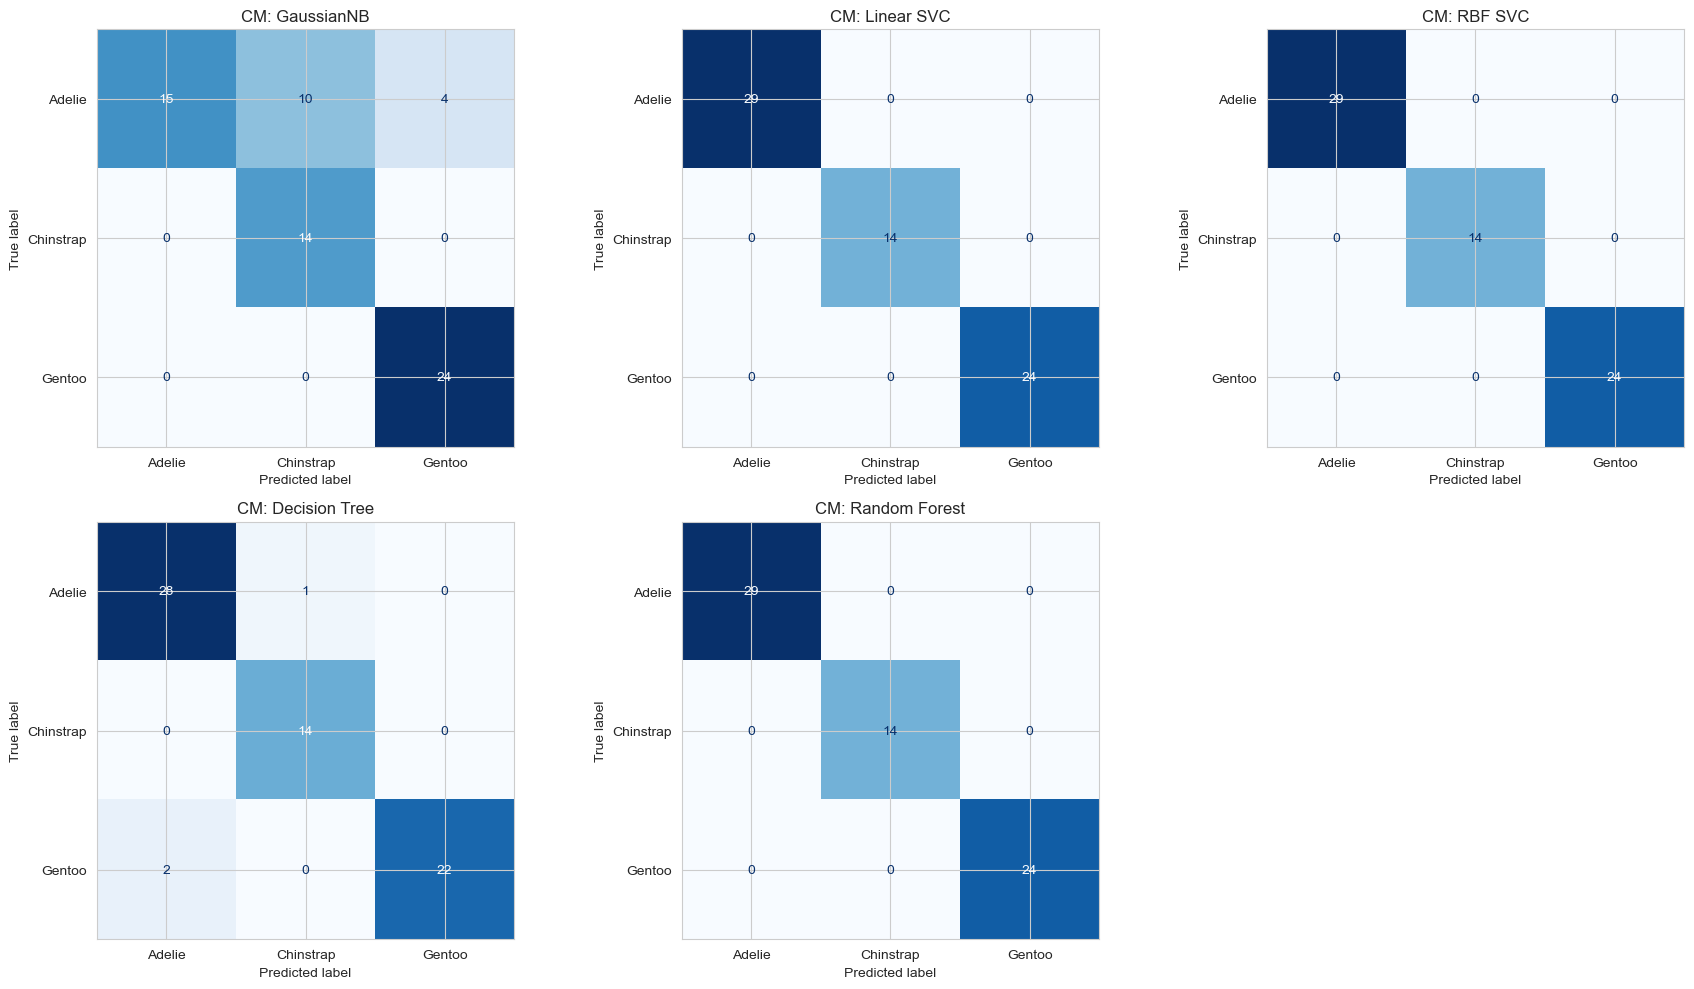

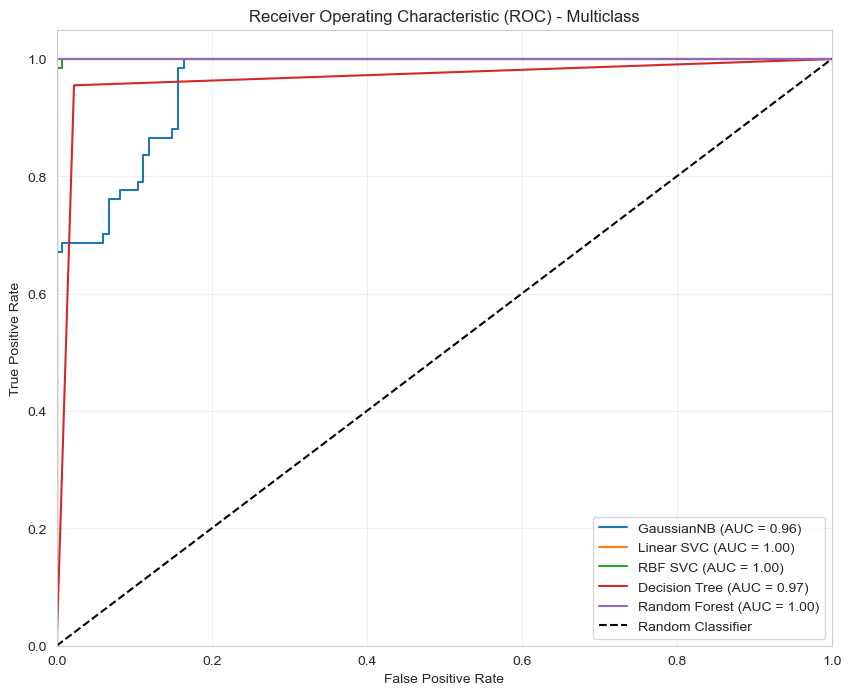

In [18]:
# TASK 3.1
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel() 
for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"CM: {name}")
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

# TASK 3.2
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 8))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else: 
        y_score = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Multiclass')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

1. Best Balance of Precision and Recall
The Linear SVC, RBF SVC, and Random Forest models provide the best balance, as they achieved perfect scores across all metrics. In their confusion matrices, all test samples fall on the main diagonal, meaning there are zero false positives and zero false negatives for any species.

2. Hardest Species Pair to Distinguish
The Adelie and Chinstrap species pair is clearly the hardest for the models to distinguish.

Evidence: In the GaussianNB confusion matrix, 10 Adelie penguins were misclassified as Chinstrap, and 4 were misclassified as Gentoo. Even the Decision Tree struggled slightly, misclassifying 1 Adelie as a Chinstrap and 2 Gentoos as Adelies.

Biological/Feature Reason: Adelie and Chinstrap penguins are physically much more similar in scale than Gentoos. Gentoos are significantly larger in terms of body mass and flipper length, making them easy for the model to "set aside" in a distinct cluster. Adelie and Chinstrap penguins have overlapping ranges for body mass and flipper length, forcing the model to rely almost entirely on subtle differences in bill shape (bill length vs. depth) to tell them apart.

3. Final Recommendation
I recommend the Linear SVC.

Performance: It achieved a perfect AUC of 1.00 and a perfect confusion matrix.

Efficiency: While Random Forest also performed perfectly, a Linear SVC is mathematically simpler and more computationally efficient.

Generalization: The ROC curve for Linear SVC (and RBF) shows an immediate jump to a 1.0 True Positive Rate with 0.0 False Positives, suggesting the linear decision boundaries are extremely well-defined for this dataset.

In summary, while the ensemble power of the Random Forest is impressive, the Linear SVC provides the same level of accuracy with a more "parsimonious" (simple and elegant) model structure.

In [19]:
# TASK 4
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the base model
rf = RandomForestClassifier(random_state=42)

# 2. Define the hyperparameter grid
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10]
}

# 3. Run GridSearchCV (5-fold CV, scoring on weighted F1)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1 # Uses all available processors
)

grid_search.fit(X_train, y_train)

# 4. Report Best Parameters and CV Score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {grid_search.best_score_:.4f}")

from sklearn.metrics import f1_score

best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

tuned_f1 = f1_score(y_test, y_pred_tuned, average='weighted')
print(f"Tuned Model Test F1: {tuned_f1:.4f}")

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best Cross-Validation F1 Score: 0.9962
Tuned Model Test F1: 1.0000


Reflection on Hyperparameter Tuning Results
Based on the output provided, here is a breakdown of what these numbers signify for your model's reliability and future performance.

1. Was the improvement significant?
In short: No. Your default Random Forest already achieved a perfect 1.0000 on the test set in Task 2. After tuning, the test score remains 1.0000. Because the model was already performing at the theoretical maximum, there was no room for "improvement" in the final metric.

However, notice that the Best Cross-Validation F1 Score is 0.9962. This is actually more informative than the perfect test score. It tells us that across different "folds" of your training data, the model occasionally missed a penguin, but maintained near-perfect accuracy. This gives us much higher confidence that the model is truly robust.

2. Is there a risk of overfitting to the validation folds?
Yes, technically there is always a risk. When we run GridSearchCV, the search "picks" the parameters that performed best on those specific validation folds.

If the search space is too large and the dataset is too small, you can end up with parameters that are "over-tuned" to the quirks of the training data.

In your case: The risk is low. The fact that your Tuned Model Test F1 (on data the grid search never saw) is still 1.0000 suggests that the parameters found are genuinely excellent and not just overfitted to the validation folds.

3. When is hyperparameter tuning most impactful?
Hyperparameter tuning is most useful in the following scenarios:

Underperforming Default Models: When your baseline model scores are low (e.g., 0.70 or 0.80), tuning can often bridge the gap to 0.90+ by finding the right complexity.

Large, Complex Datasets: In datasets with thousands of features or significant noise, the default settings for max_depth or min_samples_split are rarely optimal.

Preventing Overfitting: Sometimes tuning is used to decrease accuracy on the training set to increase it on the test set (regularization). For example, limiting max_depth prevents a tree from growing too complex and memorizing the noise.

Resource Constraints: Tuning n_estimators (the number of trees) helps find the "sweet spot" where you get high accuracy without wasting computational power or memory on unnecessary trees.

Summary of Best Parameters Found
Your search favored a relatively simple configuration:

n_estimators: 50 (The model achieved perfection with only 50 trees; it didn't even need 100 or 200).

min_samples_split: 2 (The model is allowed to be quite specific).

max_depth: None (The trees were allowed to grow until all leaves were pure).